#1 Simulating 1-D RV's session. 

#1.1 Binomial RV, convergence to the mean.

Core idea: Each new data point matters less, and randomness cancels itself out.

In [1]:
import numpy as np

In [2]:
p = 0.3
N = 10
samples = np.random.binomial(1,p,size=N)
print(samples)

[0 1 0 1 0 1 1 0 0 0]


In [3]:
empirical_mean = np.mean(samples)
print(empirical_mean)

0.4


In [4]:
N = 1000

In [7]:
samples = np.random.binomial(1,p,size=N)
empirical_mean = np.mean(samples)
print("Empirical mean: ", empirical_mean)
print("Theoretical mean: ", p)

Empirical mean:  0.308
Theoretical mean:  0.3


In [8]:
import matplotlib.pyplot as plt

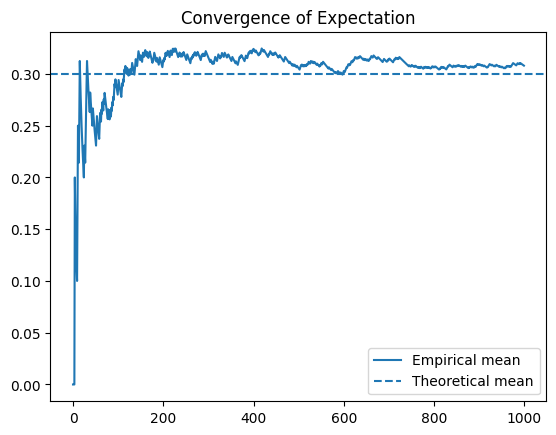

In [10]:
running_mean = np.cumsum(samples) / np.arange(1, N+1)
plt.plot(running_mean, label = "Empirical mean")
plt.axhline(y=p, linestyle = '--', label = "Theoretical mean")
plt.legend()
plt.title("Convergence of Expectation")
plt.show()

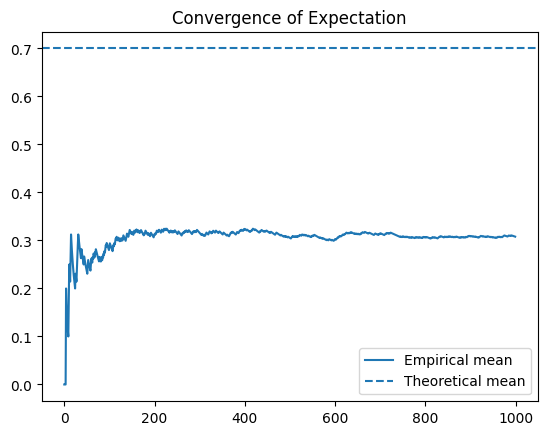

In [11]:
p=0.7
running_mean = np.cumsum(samples) / np.arange(1, N+1)
plt.plot(running_mean, label = "Empirical mean")
plt.axhline(y=p, linestyle = '--', label = "Theoretical mean")
plt.legend()
plt.title("Convergence of Expectation")
plt.show()

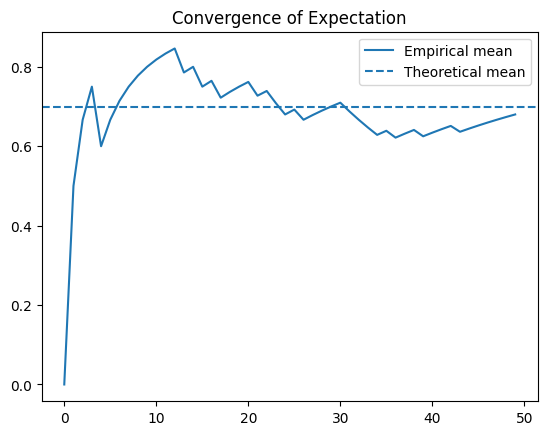

In [13]:
p=0.7 
N=50
samples = np.random.binomial(1,p,size=N)
running_mean = np.cumsum(samples) / np.arange(1, N+1)
plt.plot(running_mean, label = "Empirical mean")
plt.axhline(y=p, linestyle = '--', label = "Theoretical mean")
plt.legend()
plt.title("Convergence of Expectation")
plt.show()

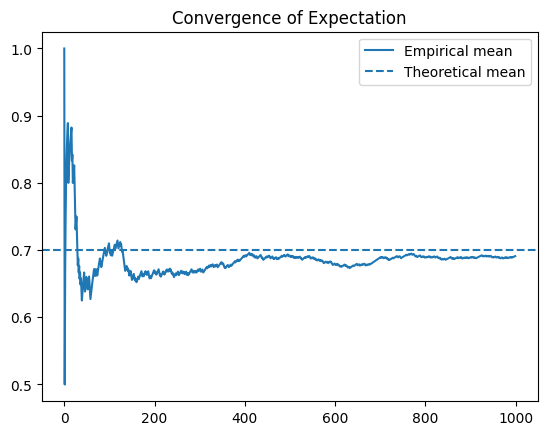

In [14]:
p=0.7 
N=1000
samples = np.random.binomial(1,p,size=N)
running_mean = np.cumsum(samples) / np.arange(1, N+1)
plt.plot(running_mean, label = "Empirical mean")
plt.axhline(y=p, linestyle = '--', label = "Theoretical mean")
plt.legend()
plt.title("Convergence of Expectation")
plt.show()

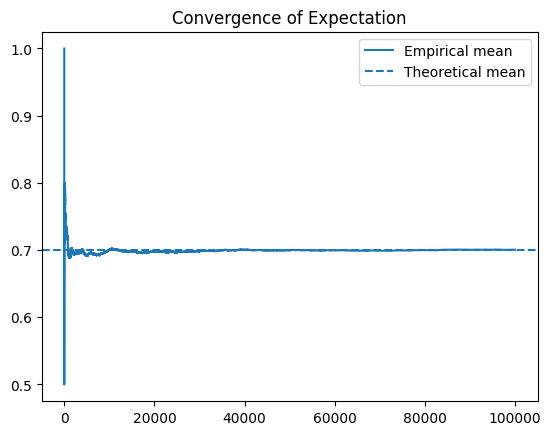

In [15]:
p=0.7 
N=100000
samples = np.random.binomial(1,p,size=N)
running_mean = np.cumsum(samples) / np.arange(1, N+1)
plt.plot(running_mean, label = "Empirical mean")
plt.axhline(y=p, linestyle = '--', label = "Theoretical mean")
plt.legend()
plt.title("Convergence of Expectation")
plt.show()

In [16]:
for n in [10, 100, 1000, 10000]:
    samples = np.random.binomial(1, p, size=n)
    print(n, np.mean(samples))

10 0.7
100 0.75
1000 0.712
10000 0.7019


#1.2 Exponential RV, generating from Uniform

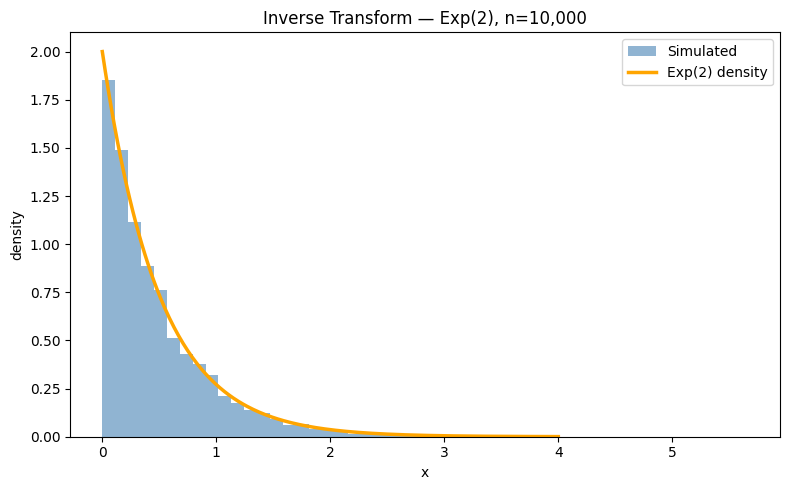

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_exponential(n, lam):
    u = np.random.uniform(0, 1, n)
    return -1/lam * np.log(u)

# Simulate
lam = 2
samples = simulate_exponential(10000, lam)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram — density=True normalizes so area=1, matching the density
ax.hist(samples, bins=50, density=True, alpha=0.6, 
        color='steelblue', label='Simulated')

# Theoretical density f(x) = lambda * exp(-lambda * x)
x = np.linspace(0, 4, 300)
ax.plot(x, lam * np.exp(-lam * x), 
        color='orange', lw=2.5, label=f'Exp({lam}) density')

ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title(f'Inverse Transform — Exp({lam}), n=10,000')
ax.legend()
plt.tight_layout()
plt.show()

#1.2 Gamma RV, as sum of Exponential, generating from Uniform 

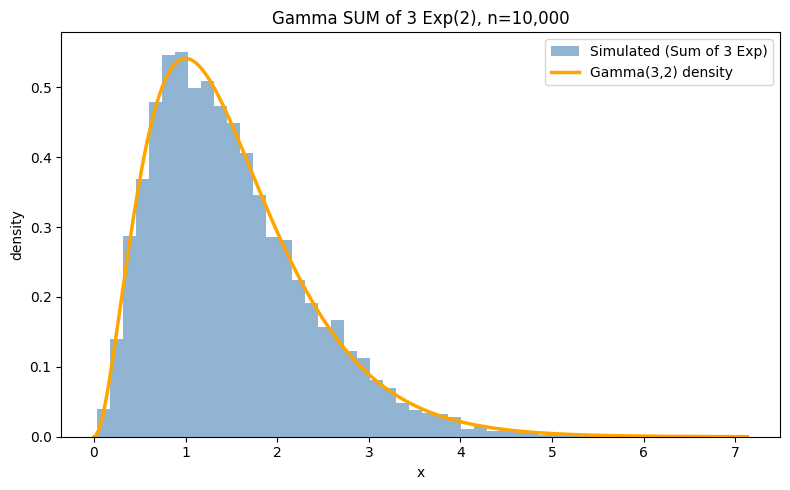

In [7]:
import numpy as np
import matplotlib.pyplot as plt
###import math
from scipy.special import gamma


def simulate_exponential(n, lam):
    u = np.random.uniform(0, 1, n)
    return -1/lam * np.log(u)

# Simulate
lam = 2
k = 3
n_samples = 10000

# Gamma as sum of Exponential RVs:
simulated_gamma = sum(simulate_exponential(n_samples, lam) 
                      for i in range(k)) #works for any k

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Simulated pdf-Histogram — density=True normalizes so area=1, matching the density
ax.hist(simulated_gamma, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Simulated (Sum of {k} Exp)')

# Generate 300 evenly spaced x-values from 0 to the maximum value in our 'gamma' array
x = np.linspace(0, max(simulated_gamma), 300)

# Theoretical Gamma PDF formula: (lam^k * x^(k-1) * e^(-lam * x)) / factorial(k-1)
numerator = (lam**k) * (x**(k-1)) * np.exp(-lam*x)
denominator = gamma(k)   # gamma(k) = (k-1)! for integer k
theoretical_gamma = numerator / denominator

# Theoretical pdf-Curve
ax.plot(x, theoretical_gamma, color='orange', 
        lw=2.5, label=f'Gamma(3,{lam}) density')


ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title(f'Gamma SUM of {k} Exp({lam}), n=10,000')
ax.legend()
plt.tight_layout()
plt.show()

#1.3 Box-Mueller for Normal RVs

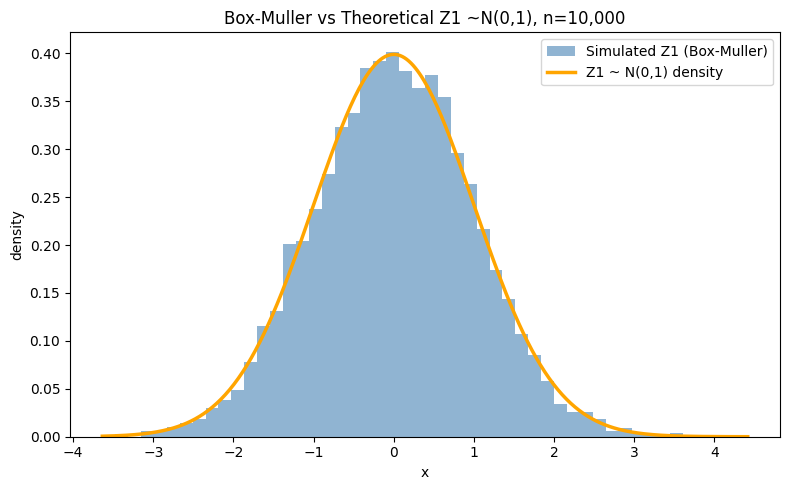

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_normal_boxmuller(n):
    u1 = np.random.uniform(0, 1, n)
    u2 = np.random.uniform(0, 1, n)
    z1 = np.sqrt((-2) * np.log(u1)) * np.cos(2 * np.pi * u2)
    z2 = np.sqrt((-2) * np.log(u1)) * np.sin(2 * np.pi * u2)
    return z1, z2

# Simulate for n_samples
n_samples = 10000
z1, z2 = simulate_normal_boxmuller(n_samples)

# Simulated Z1 plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(z1, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Simulated Z1 (Box-Muller)')

# Generate 300 evenly spaced x-values from simulated z1 for theoretical ~N(0,1) 
x = np.linspace(min(z1), max(z1), 300)

# Theoretical Z1 pdf
theoretical_z1 = (np.exp(-(x**2) / 2))/ (np.sqrt(2 * np.pi))

ax.plot(x, theoretical_z1, color='orange', 
        lw=2.5, label=f'Z1 ~ N(0,1) density')


ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title(f'Box-Muller vs Theoretical Z1 ~N(0,1), n=10,000')
ax.legend()
plt.tight_layout()
plt.show()

Plotting Z1 vs Z2 to verify independence

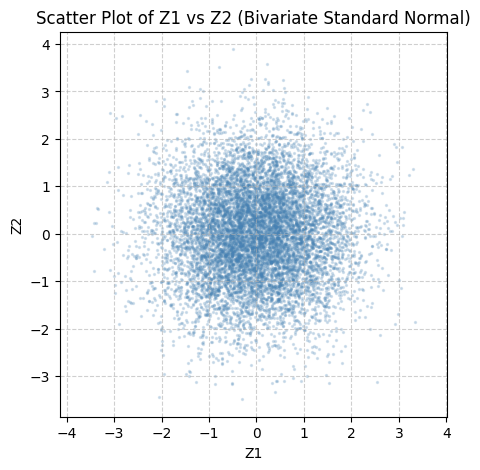

In [19]:
import matplotlib.pyplot as plt

# Set the figure size to be perfectly square
plt.figure(figsize=(5, 5))

# Create the scatter plot
# s=2 controls the dot size, alpha=0.2 makes them semi-transparent
plt.scatter(z1, z2, color='steelblue', s=2, alpha=0.2)

# Force the X and Y axes to have the exact same scale
# This is crucial! Without it, a perfect circle might look like an oval.
plt.axis('equal')

# Add context and labels
plt.title('Scatter Plot of Z1 vs Z2 (Bivariate Standard Normal)')
plt.xlabel('Z1')
plt.ylabel('Z2')

# Add a light grid for reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

(Z1,Z2) statistics

In [29]:
print(f"Z1 mean: {np.mean(z1)}")
print(f"Z1 variance: {np.var(z1)}")
print(f"Z2 variance: {np.var(z2)}")
print(f"Z1, Z2 covariance: {np.cov(z1, z2)[0, 1]}")

Z1 mean: -0.014968483666520652
Z1 variance: 0.9971985169486034
Z2 variance: 1.004929345192276
Z1, Z2 covariance: 0.015056563167516402


For Normal RV with mu=2 and sigma=3

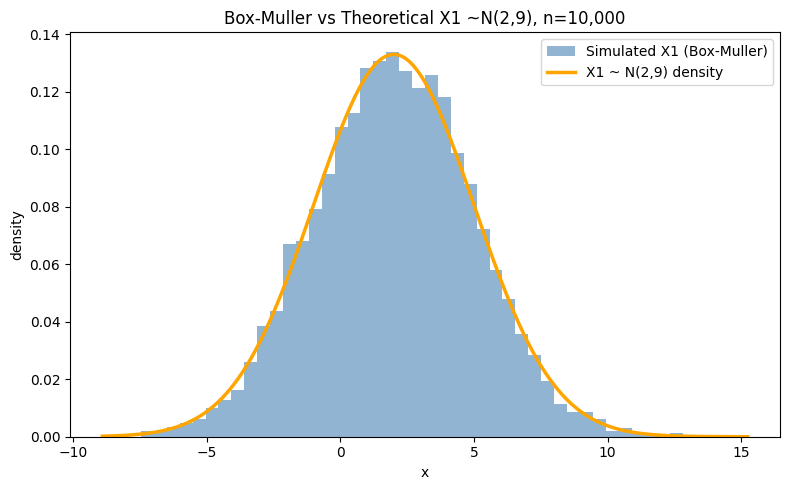

In [10]:
import numpy as np
import matplotlib.pyplot as plt

mu = 2
sigma = 3
x1 = mu + (sigma * z1)

# Simulated X1 plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(x1, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Simulated X1 (Box-Muller)')

# Generate 300 evenly spaced x-values from simulated z1 for theoretical ~N(0,1) 
x = np.linspace(min(x1), max(x1), 300)

# Theoretical X1 pdf
numerator = np.exp((-(x-mu)**2) / (2*(sigma**2)))
denominator = sigma * (np.sqrt(2 * np.pi))
theoretical_x1 = numerator / denominator

ax.plot(x, theoretical_x1, color='orange', 
        lw=2.5, label=f'X1 ~ N(2,9) density')

ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title(f'Box-Muller vs Theoretical X1 ~N(2,9), n=10,000')
ax.legend()
plt.tight_layout()
plt.show()

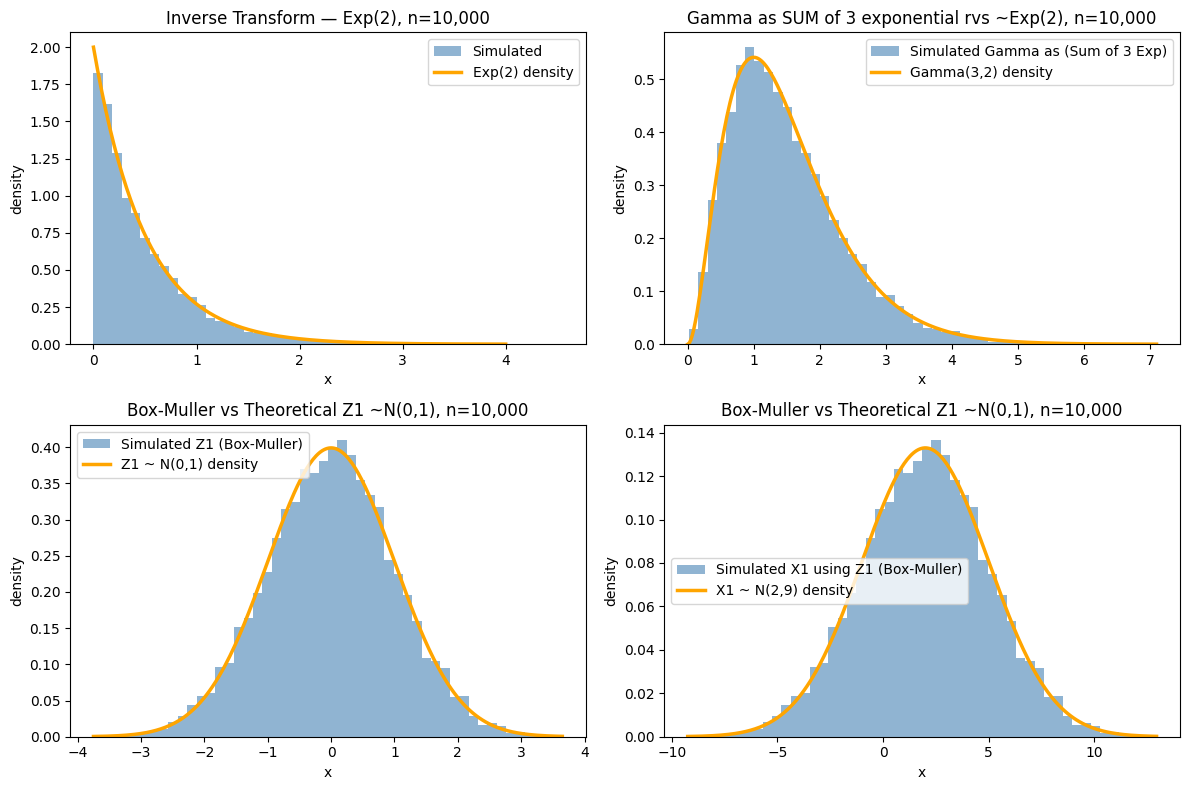

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Universal n - number of samples for all RVs:
n = 10000

# Universal preset for 4 - Plots:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#################### EXPONENTIAL #############################
# Exponential simulated function:
def simulate_exponential(n, lam):
    u = np.random.uniform(0, 1, n)
    return -1/lam * np.log(u)

# Simulate exponential
lam = 2
simulated_exp = simulate_exponential(n, lam)

# Exponential theoretical:
exp_x = np.linspace(0, 4, 300)
theoretical_exp = lam * np.exp(-lam * exp_x)


# Exponential Simulated Histogram — density=True normalizes so area=1, matching the density
axes[0, 0].hist(simulated_exp, bins=50, density=True, alpha=0.6, 
        color='steelblue', label='Simulated')


# Exponential Theoretical pdf-Curve
axes[0, 0].plot(exp_x, theoretical_exp, 
        color='orange', lw=2.5, label=f'Exp({lam}) density')

axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('density')
axes[0, 0].set_title(f'Inverse Transform — Exp({lam}), n=10,000')
axes[0, 0].legend()
#plt.tight_layout()
#plt.show()

#################### GAMMA  #############################
from scipy.special import gamma

# Gamma Simulation parameters:
k = 3

# Gamma simulated as sum of Exponential RVs:
simulated_gamma = sum(simulate_exponential(n, lam) 
                      for i in range(k)) #works for any k


# Gamma Theoretical PDF formula: (lam^k * x^(k-1) * e^(-lam * x)) / factorial(k-1):
gamma_x = np.linspace(0, max(simulated_gamma), 300) # 300 evenly spaced x-values from 0 to the maximum value in our 'gamma' array
numerator = (lam**k) * (gamma_x**(k-1)) * np.exp(-lam*gamma_x)
denominator = gamma(k)   # gamma(k) = (k-1)! for integer k
theoretical_gamma = numerator / denominator


# Gamma Simulated Histogram — density=True normalizes so area=1, matching the density
axes[0, 1].hist(simulated_gamma, bins=50, density=True, alpha=0.6, 
        color='steelblue', label=f'Simulated Gamma as (Sum of {k} Exp)')

# Gamma Theoretical pdf-Curve:
axes[0, 1].plot(gamma_x, theoretical_gamma, color='orange', 
        lw=2.5, label=f'Gamma({k},{lam}) density')


axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('density')
axes[0, 1].set_title(f'Gamma as SUM of {k} exponential rvs ~Exp({lam}), n=10,000')
axes[0, 1].legend()

#################### Z1,Z2 ~ N(0,1)  #############################

# Standard normal simulated using Box-Mullerfunction:
def simulate_normal_boxmuller(n):
    u1 = np.random.uniform(0, 1, n)
    u2 = np.random.uniform(0, 1, n)
    z1 = np.sqrt((-2) * np.log(u1)) * np.cos(2 * np.pi * u2)
    z2 = np.sqrt((-2) * np.log(u1)) * np.sin(2 * np.pi * u2)
    return z1, z2

# Z1 STD Normal Simulated 
z1, z2 = simulate_normal_boxmuller(n)

# Z1 Theoretical pdf
normal_x = np.linspace(min(z1), max(z1), 300)  # Generate 300 evenly spaced x-values from simulated z1 for theoretical ~N(0,1) 
theoretical_z1 = (np.exp(-(normal_x**2) / 2))/ (np.sqrt(2 * np.pi))

# Z1 Simulated Histogram — density=True normalizes so area=1, matching the density
axes[1, 0].hist(z1, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Simulated Z1 (Box-Muller)')

# Z1 Theoretical pdf-Curve
axes[1, 0].plot(normal_x, theoretical_z1, color='orange', 
        lw=2.5, label=f'Z1 ~ N(0,1) density')


axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('density')
axes[1, 0].set_title(f'Box-Muller vs Theoretical Z1 ~N(0,1), n=10,000')
axes[1, 0].legend()

#################### X ~ N(2,9)  #############################

# Normal Simulation parameters:
mu = 2
sigma = 3

# Normal simulation:
x1 = mu + (sigma * z1)

# X1 Theoretical pdf
normal_x1 = np.linspace(min(x1), max(x1), 300) # Generate 300 evenly spaced x-values from simulated z1 for theoretical ~N(0,1) 

numerator = np.exp((-(normal_x1-mu)**2) / (2*(sigma**2)))
denominator = sigma * (np.sqrt(2 * np.pi))
theoretical_x1 = numerator / denominator

# Z1 Simulated Histogram — density=True normalizes so area=1, matching the density
axes[1, 1].hist(x1, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Simulated X1 using Z1 (Box-Muller)')

# Z1 Theoretical pdf-Curve
axes[1, 1].plot(normal_x1, theoretical_x1, color='orange', 
        lw=2.5, label=f'X1 ~ N(2,9) density')


axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('density')
axes[1, 1].set_title(f'Box-Muller vs Theoretical Z1 ~N(0,1), n=10,000')
axes[1, 1].legend()

################### PLOT SHOW  ##############################
plt.tight_layout()
plt.show()

#2 Simulating MVN RV's session. 

In [15]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([1, 3])
Sigma = np.array([[4, 3], [3, 9]])

# Step 1: Cholesky decomposition
L = np.linalg.cholesky(Sigma)

# Step 2: simulate iid N(0,1)
n_mvn = 5000
z1, z2 = simulate_normal_boxmuller(n_mvn) # your code — shape (2, n)
np.array([z1, z2])

# Additional step to prepare mu for sum up with L*Z
mu_col = mu.reshape(2, 1)

# Step 3: transform
X = mu_col + (L @ Z) # your code
print("Shape of x_2d:", X.shape) # checking the shape of X for # X should have shape (2, n)
print ('X[1] with Variance = 4:', X[0])
print ('X[2] with Variance = 9:', X[1])
print(np.mean(X, axis=1))
print(np.cov(X))

Shape of x_2d: (2, 5000)
X[1] with Variance = 4: [ 0.09373513 -1.06237021 -0.22891505 ...  3.26758773  1.45948949
  2.53536604]
X[2] with Variance = 9: [-1.67837534  0.6808585   4.08947357 ...  0.58658749  3.56960435
  2.66619697]
[0.96951751 2.9846628 ]
[[3.95543047 3.08031009]
 [3.08031009 9.05659387]]


/var/folders/pl/bll7lckx0p9dg0g6qf5zkrh00000gn/T/ipykernel_13139/2412327490.py:19: RuntimeWarning: divide by zero encountered in matmul
  X = mu_col + (L @ Z) # your code
/var/folders/pl/bll7lckx0p9dg0g6qf5zkrh00000gn/T/ipykernel_13139/2412327490.py:19: RuntimeWarning: overflow encountered in matmul
  X = mu_col + (L @ Z) # your code
/var/folders/pl/bll7lckx0p9dg0g6qf5zkrh00000gn/T/ipykernel_13139/2412327490.py:19: RuntimeWarning: invalid value encountered in matmul
  X = mu_col + (L @ Z) # your code
